In [30]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import logging

logging.getLogger("torch").setLevel(logging.ERROR)


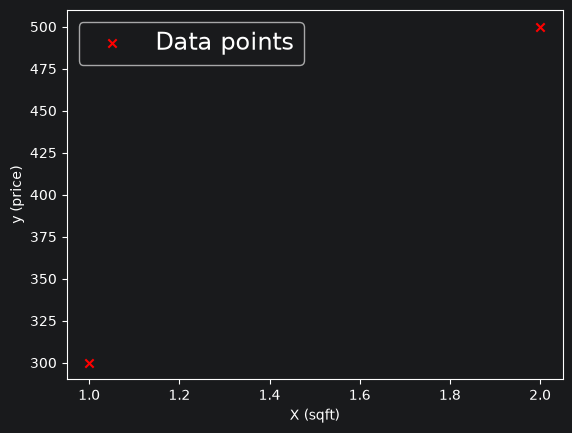

In [31]:
X_train = np.array([[1.0] , [2.0]] ,dtype=np.float32)
y_train = np.array([[300.0] , [500.0]] , dtype=np.float32)

fig , ax = plt.subplots(1,1)
ax.scatter(X_train , y_train , marker='x',c='r',label='Data points')
ax.legend(fontsize='xx-large')
ax.set_xlabel('X (sqft)')
ax.set_ylabel('y (price)')
plt.show()

# Regression/Linear model
The function implemented by a neuron with no activation is the same as in Coursera 1, linear regression :
$$ f_{\mathbf{w},b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$
$$ f_{\mathbf{w},b}(x^{(i)} = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$

In [32]:
linear_layer = nn.Linear(in_features=1, out_features=1)
print(linear_layer)

Linear(in_features=1, out_features=1, bias=True)


In [33]:
print(linear_layer.weight)
print(linear_layer.bias)

Parameter containing:
tensor([[0.2105]], requires_grad=True)
Parameter containing:
tensor([0.4691], requires_grad=True)


In [39]:
x_new = torch.from_numpy(X_train[0].reshape(1,1)).float()

a1 = linear_layer(x_new)

print(f"x_new : {x_new} and x_train : {X_train[0]}")
print(a1)


x_new : tensor([[1.]]) and x_train : [1.]
tensor([[0.6797]], grad_fn=<AddmmBackward0>)


In [40]:
w_one = linear_layer.weight
b_one = linear_layer.bias

print(f"weight : {w_one} and bias : {b_one}")

weight : Parameter containing:
tensor([[0.2105]], requires_grad=True) and bias : Parameter containing:
tensor([0.4691], requires_grad=True)


In [41]:
w_tensor = linear_layer.weight
b_tensor = linear_layer.bias

alin_torch = torch.matmul(x_new , w_tensor.T) + b_tensor
print(alin_torch)

tensor([[0.6797]], grad_fn=<AddBackward0>)


In [44]:
model = nn.Sequential()
model.add_module("L1" , nn.Linear(in_features=1,out_features=1))
model.add_module("Sigmoid" , nn.Sigmoid())

l1_layer = model.L1
w = l1_layer.weight.detach().cpu().numpy()
b = l1_layer.bias.detach().cpu().numpy()

print(f"weight : {w} and bias : {b}")
print(w.shape , b.shape)

weight : [[0.4709748]] and bias : [-0.84281063]
(1, 1) (1,)


In [48]:
model.eval()

x_input = torch.tensor(X_train[0].reshape(1,1),dtype=torch.float32)

with torch.inference_mode():
    a1 = model(x_input)

print(a1)

tensor([[0.4081]])


In [50]:
X_tensor = torch.tensor([[200.0,17.5]], dtype=torch.float32)

layer_1 = nn.Linear(in_features=2,out_features=3)
activ_1 = nn.Sigmoid()
layer_2 = nn.Linear(in_features=3, out_features=1)
activ_2 = nn.Sigmoid()

activ_1 = activ_1(layer_1(X_tensor))
activ_2 = activ_2(layer_2(activ_1))

print(activ_2)


tensor([[0.6819]], grad_fn=<SigmoidBackward0>)


In [ ]:

class ModelFactory:
    @staticmethod
    def create_model(model_type: str , num_class: int) -> nn.Module:
        if model_type == "resnet18":
            model = torch.hub.load('pytorch/vision','resnet18',pretrained=True)
            model.fc = nn.Linear(model.fc.in_features , num_class)
            return model
        elif model_type == "linear":
            return nn.Linear(512,num_class)
        raise ValueError(f"Unknown model type: {model_type}")
